# LSTM Baseline Models (Revised)

Notebook ini mengimplementasikan 3 model LSTM untuk forecasting Carbon Intensity (CI) dan Renewable Energy (RE):

| Model | Input | Output |
|---|---|---|
| **Univariate LSTM (CI)** | CI + lag CI + MSTL CI + seasonal dummies | CI (1-step ahead) |
| **Univariate LSTM (RE)** | RE + lag RE + MSTL RE + seasonal dummies | RE (1-step ahead) |
| **Multivariate LSTM** | CI + RE + all lags + all MSTL + seasonal dummies | CI & RE (2 output) |

**Windowing**: 24 jam ke belakang → 1 jam ke depan (one-step ahead)

---

## Setup & Data Loading

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.data_loader import TimeSeriesDataLoader
from src.models.deep_learning import LSTMForecaster
from src.evaluation.metrics import ModelEvaluator

# Plotting config
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 12

# Constants
LOOK_BACK = 24       # 24 jam ke belakang
FORECAST_HORIZON = 1 # 1-step ahead
TRAIN_RATIO = 0.8
DATA_PATH = '../data/processed/dataset_CI_RE_2024_2025_cleaned.csv'

In [2]:
# Load data
loader = TimeSeriesDataLoader()
df_raw = loader.load_and_clean(DATA_PATH)

print(f"\nDataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nHead:")
df_raw.head()

Loading data from ../data/processed/dataset_CI_RE_2024_2025_cleaned.csv...
Data cleaned. Shape: (17544, 2)
Range: 2024-01-01 00:00:00 → 2025-12-31 23:00:00

Dataset shape: (17544, 2)
Columns: ['carbon_intensity', 'renewable_percentage']

Head:


,carbon_intensity,renewable_percentage
datetime,,
2024-01-01 00:00:00,661.60,16.06
2024-01-01 01:00:00,658.96,16.19
2024-01-01 02:00:00,654.67,16.56
2024-01-01 03:00:00,656.25,16.41
2024-01-01 04:00:00,656.69,16.37


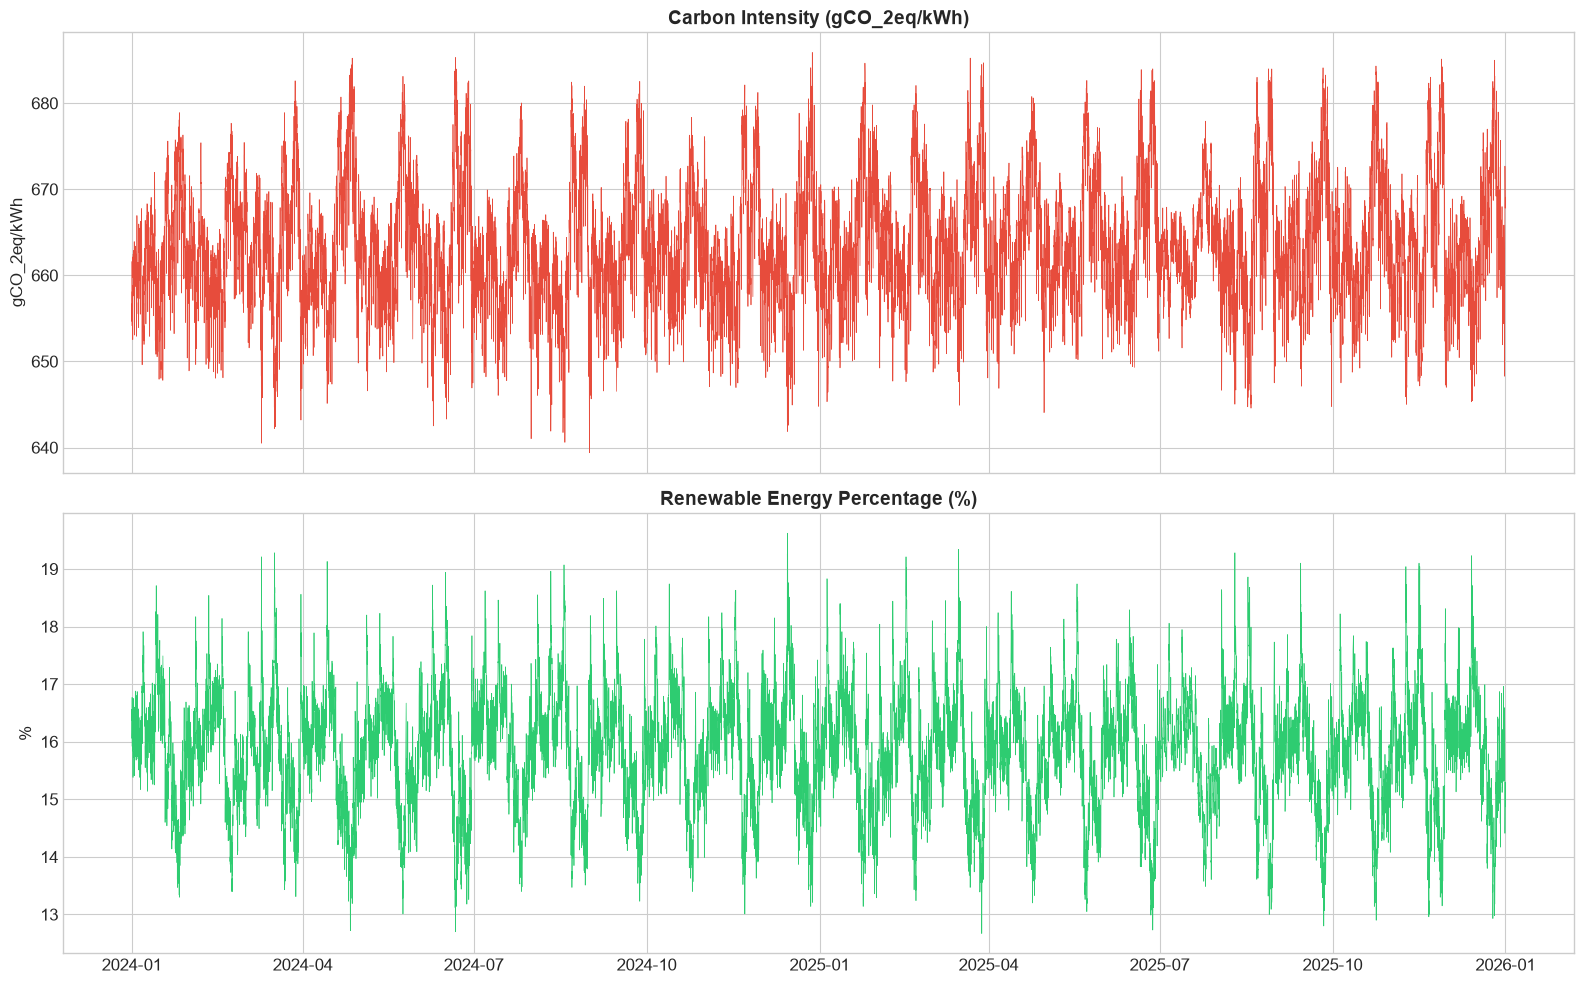

In [3]:
# Quick visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df_raw.index, df_raw['carbon_intensity'], color='#e74c3c', linewidth=0.5)
axes[0].set_title('Carbon Intensity (gCO_2eq/kWh)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('gCO_2eq/kWh')

axes[1].plot(df_raw.index, df_raw['renewable_percentage'], color='#2ecc71', linewidth=0.5)
axes[1].set_title('Renewable Energy Percentage (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

## Feature Engineering

### MSTL Decomposition

Menguraikan sinyal menjadi: **Trend + Seasonal (24h) + Seasonal (168h) + Residual**

In [4]:
# MSTL Decomposition (daily=24h, weekly=168h)
print("Menjalankan MSTL decomposition...")
df_features = loader.add_mstl_decomposition(df_raw, periods=(24, 168))

print(f"\nKolom setelah MSTL:")
print(df_features.columns.tolist())

Menjalankan MSTL decomposition...
  MSTL decomposition untuk carbon_intensity (periods=(24, 168))...
  MSTL decomposition untuk renewable_percentage (periods=(24, 168))...
  MSTL selesai. Shape: (17544, 10)

Kolom setelah MSTL:
['carbon_intensity', 'renewable_percentage', 'CI_trend', 'CI_resid', 'CI_seasonal_24', 'CI_seasonal_168', 'RE_trend', 'RE_resid', 'RE_seasonal_24', 'RE_seasonal_168']


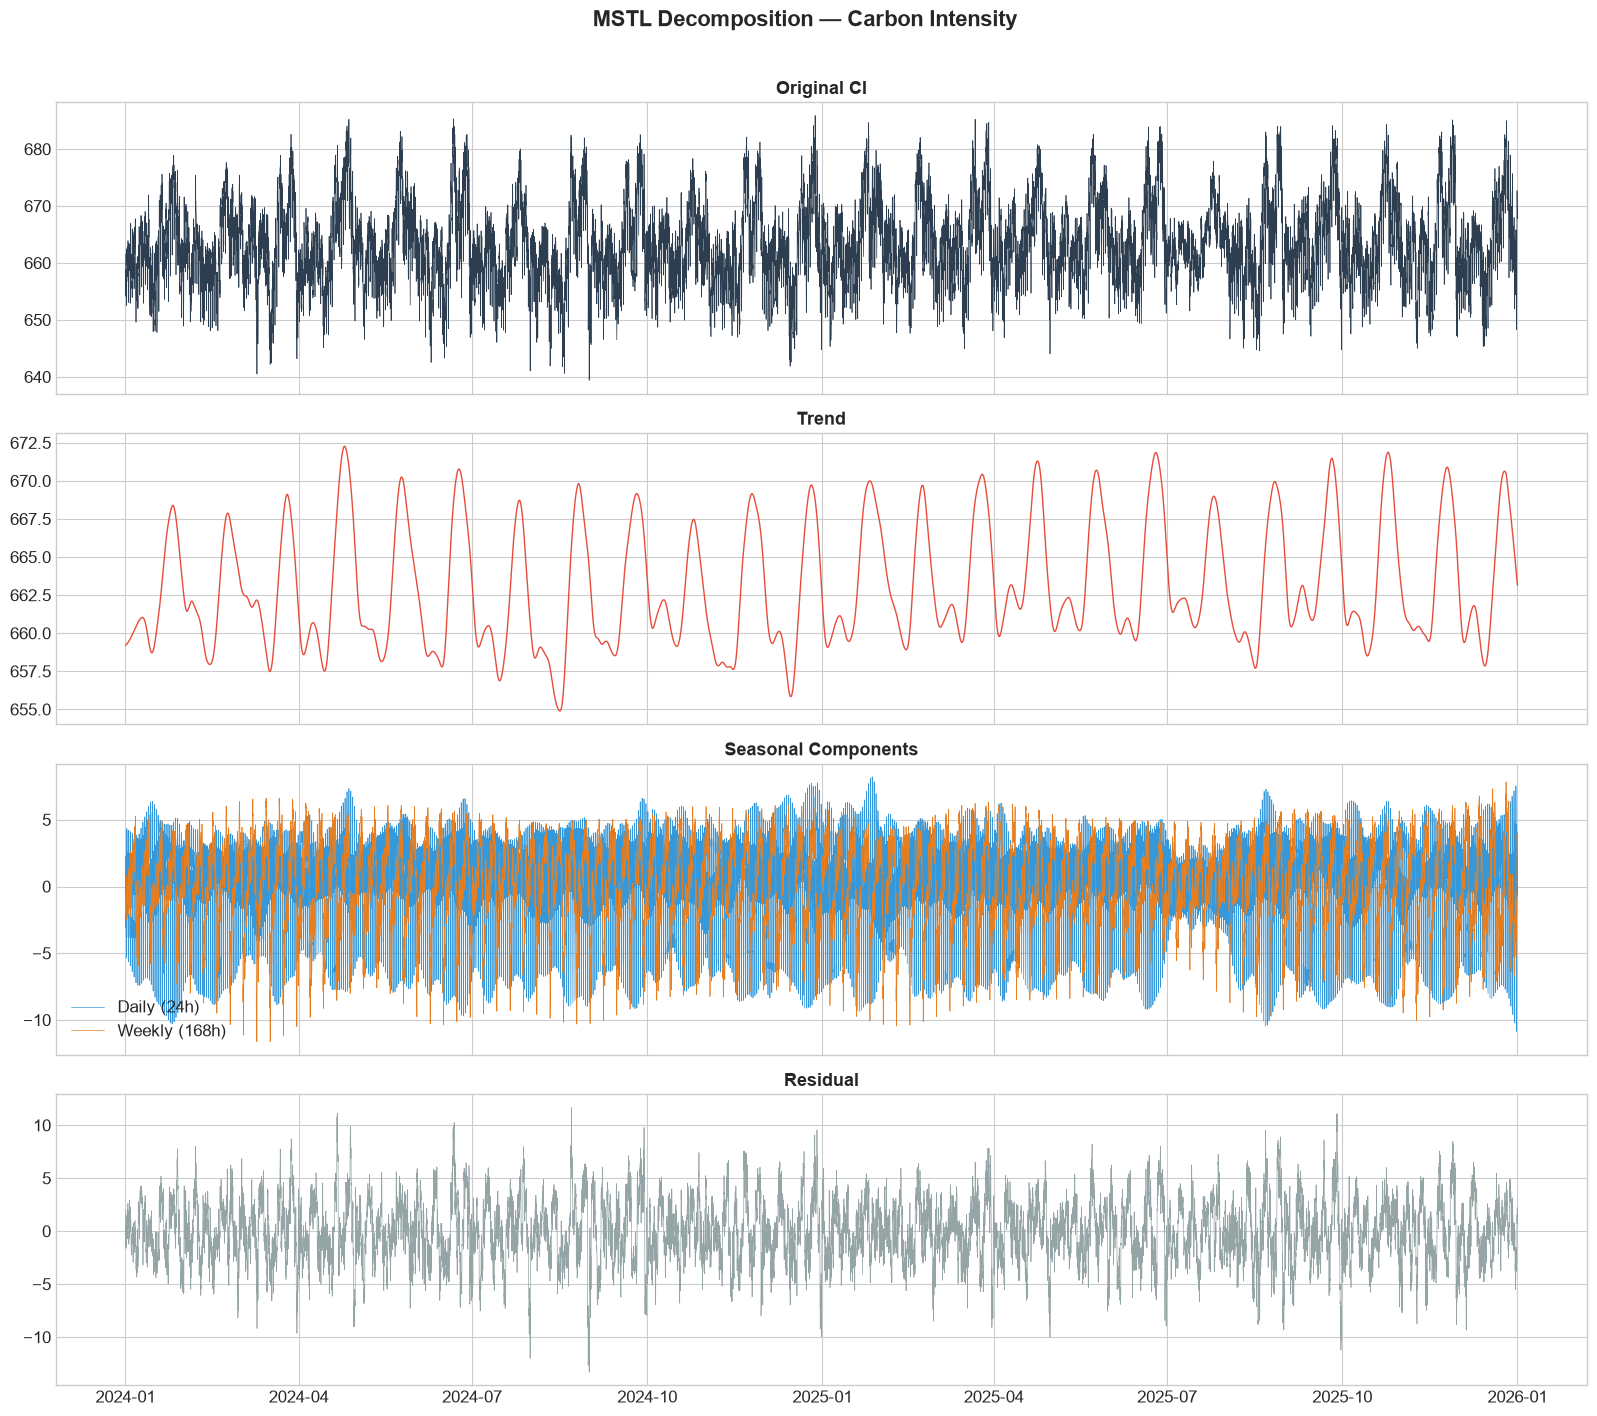

In [5]:
# Visualisasi MSTL untuk CI
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(df_features.index, df_features['carbon_intensity'], color='#2c3e50', linewidth=0.5)
axes[0].set_title('Original CI', fontsize=13, fontweight='bold')

axes[1].plot(df_features.index, df_features['CI_trend'], color='#e74c3c', linewidth=1)
axes[1].set_title('Trend', fontsize=13, fontweight='bold')

axes[2].plot(df_features.index, df_features['CI_seasonal_24'], color='#3498db', linewidth=0.5, label='Daily (24h)')
axes[2].plot(df_features.index, df_features['CI_seasonal_168'], color='#e67e22', linewidth=0.5, label='Weekly (168h)')
axes[2].set_title('Seasonal Components', fontsize=13, fontweight='bold')
axes[2].legend()

axes[3].plot(df_features.index, df_features['CI_resid'], color='#95a5a6', linewidth=0.5)
axes[3].set_title('Residual', fontsize=13, fontweight='bold')

plt.suptitle('MSTL Decomposition — Carbon Intensity', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### PACF Analysis & Lag Generation

Menentukan lag yang signifikan dari PACF untuk dijadikan input features.

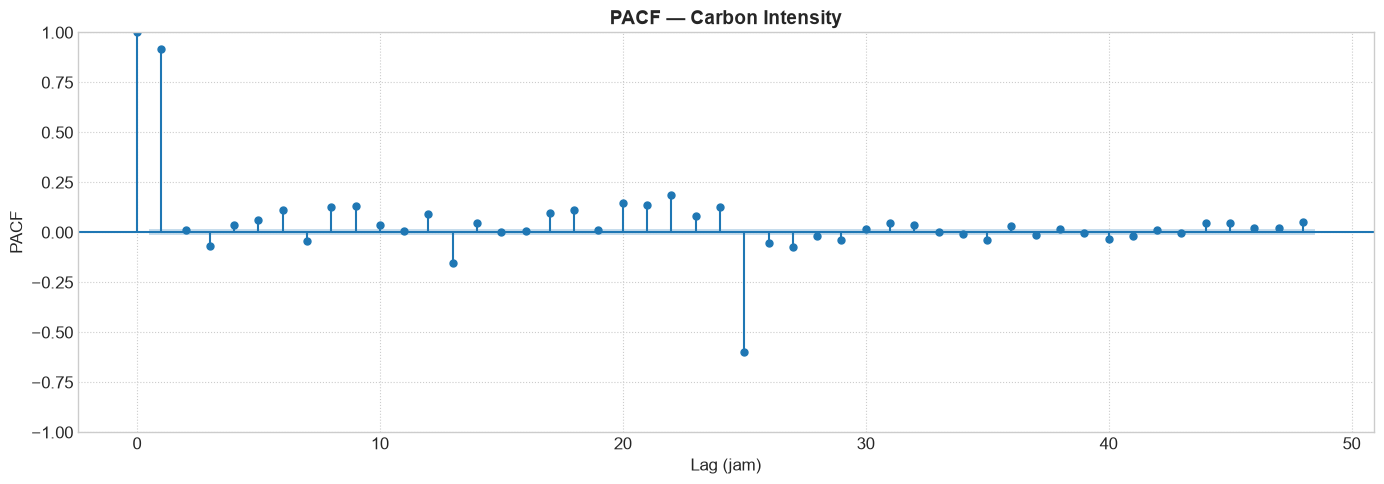

Lag CI signifikan (p<0.05): [1, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 35, 36, 38, 40, 41, 44, 45, 46, 47, 48]
Threshold: ±0.014798


In [6]:
# PACF untuk CI
max_lag = 48
ci_series = df_raw['carbon_intensity']

fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(ci_series, lags=max_lag, method='ywm', ax=ax)
ax.set_title('PACF — Carbon Intensity', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag (jam)')
ax.set_ylabel('PACF')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Hitung lag signifikan
n_ci = len(ci_series)
pacf_values_ci = pacf(ci_series, nlags=max_lag, method='ywm')
significance_ci = 1.96 / np.sqrt(n_ci)
significant_lags_ci = [i for i in range(1, max_lag + 1) if abs(pacf_values_ci[i]) > significance_ci]

print(f"Lag CI signifikan (p<0.05): {significant_lags_ci}")
print(f"Threshold: ±{significance_ci:.6f}")

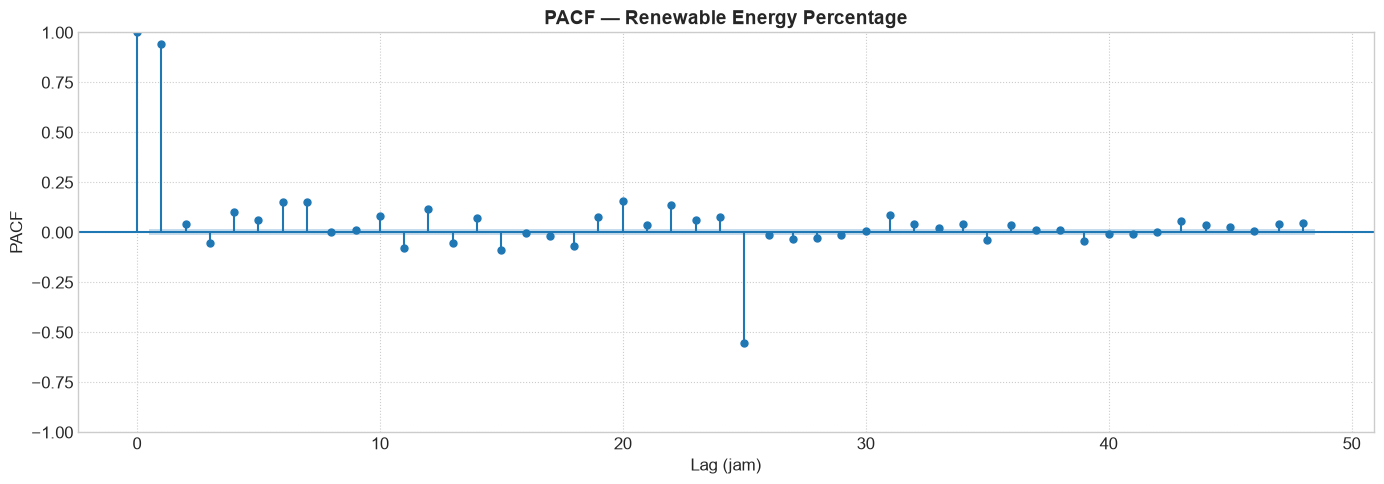

Lag RE signifikan (p<0.05): [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 34, 35, 36, 39, 43, 44, 45, 47, 48]
Threshold: ±0.014798


In [7]:
# PACF untuk RE
re_series = df_raw['renewable_percentage']

fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(re_series, lags=max_lag, method='ywm', ax=ax)
ax.set_title('PACF — Renewable Energy Percentage', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag (jam)')
ax.set_ylabel('PACF')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Hitung lag signifikan
n_re = len(re_series)
pacf_values_re = pacf(re_series, nlags=max_lag, method='ywm')
significance_re = 1.96 / np.sqrt(n_re)
significant_lags_re = [i for i in range(1, max_lag + 1) if abs(pacf_values_re[i]) > significance_re]

print(f"Lag RE signifikan (p<0.05): {significant_lags_re}")
print(f"Threshold: ±{significance_re:.6f}")

In [ ]:
# Tambahkan lag features ke dataframe
print("Menambahkan PACF lag features...")
df_features = loader.add_pacf_lags(df_features, 
                                    target_col='carbon_intensity', 
                                    lags=significant_lags_ci, 
                                    prefix='CI')

df_features = loader.add_pacf_lags(df_features, 
                                    target_col='renewable_percentage', 
                                    lags=significant_lags_re, 
                                    prefix='RE')

print(f"Columns setelah lag: {len(df_features.columns)}")
print([c for c in df_features.columns if 'lag' in c])

Menambahkan PACF lag features...
Columns setelah lag: 84
['CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_17', 'CI_lag_18', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_28', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_38', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33', 'RE_lag_34', 'RE_lag_35', 'RE_lag_36', 'RE_lag_39', 'RE_lag_43', 'RE_lag_44', 'RE_lag_45', 'RE_lag_47', 'RE_lag_

### Time Features (Cyclical Encoding)

Menggunakan sin/cos encoding untuk hour, dayofweek, dan month

In [9]:
# Tambah time features (cyclical encoding)
df_features = loader.add_time_features(df_features)

# Drop NaN dari lag shift
print(f"Shape sebelum dropna: {df_features.shape}")
df_features.dropna(inplace=True)
print(f"Shape setelah dropna: {df_features.shape}")

print(f"\nSemua kolom ({len(df_features.columns)}):")
print(df_features.columns.tolist())

Shape sebelum dropna: (17544, 90)
Shape setelah dropna: (17496, 90)

Semua kolom (90):
['carbon_intensity', 'renewable_percentage', 'CI_trend', 'CI_resid', 'CI_seasonal_24', 'CI_seasonal_168', 'RE_trend', 'RE_resid', 'RE_seasonal_24', 'RE_seasonal_168', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_17', 'CI_lag_18', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_28', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_38', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag

In [10]:
df_features.describe()

,carbon_intensity,renewable_percentage,CI_trend,CI_resid,CI_seasonal_24,CI_seasonal_168,RE_trend,RE_resid,RE_seasonal_24,RE_seasonal_168,...,RE_lag_44,RE_lag_45,RE_lag_47,RE_lag_48,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
count,17496.000000,17496.000000,17496.000000,17496.000000,17496.000000,17496.000000,17496.000000,17496.000000,17496.000000,17496.000000,...,17496.000000,17496.000000,17496.000000,17496.000000,1.749600e+04,1.749600e+04,17496.000000,17496.000000,17496.000000,1.749600e+04
mean,663.148475,15.845168,663.148979,0.004357,-0.000264,-0.004597,15.845113,-0.000379,0.000005,0.000429,...,15.846244,15.846297,15.846388,15.846396,-1.751381e-17,-5.848088e-17,0.001337,-0.000305,-0.002793,-6.307375e-03
std,7.283457,1.006126,4.001901,2.948340,3.223189,3.213976,0.621790,0.350037,0.303770,0.502198,...,1.005927,1.005933,1.005947,1.005948,7.071270e-01,7.071270e-01,0.707563,0.706690,0.707849,7.063710e-01
min,639.400000,12.670000,654.896414,-13.321134,-10.847972,-11.619550,14.468169,-1.296551,-1.047488,-0.997587,...,12.670000,12.670000,12.670000,12.670000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000,-1.000000e+00
25%,658.190000,15.200000,660.049903,-1.955004,-1.512254,-2.021887,15.266983,-0.233258,-0.225963,-0.356896,...,15.200000,15.200000,15.200000,15.200000,-7.071068e-01,-7.071068e-01,-0.781831,-0.900969,-0.500000,-8.660254e-01
50%,662.660000,15.928581,661.894777,-0.095778,0.596798,0.161573,16.041880,0.008936,0.016963,-0.086683,...,15.930000,15.930000,15.930000,15.930000,6.123234e-17,-6.123234e-17,0.000000,-0.222521,0.000000,-1.836970e-16
75%,667.560000,16.490000,666.676182,1.990973,2.303323,2.555142,16.354171,0.238944,0.215545,0.180179,...,16.490000,16.490000,16.490000,16.490000,7.071068e-01,7.071068e-01,0.781831,0.623490,0.866025,5.000000e-01
max,685.890000,19.620000,672.274080,11.671035,8.212273,7.833959,16.915496,1.140672,0.982119,1.984165,...,19.620000,19.620000,19.620000,19.620000,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000,1.000000e+00


### Feature Column Definitions

Definisikan kolom-kolom yang dipakai untuk masing-masing model.

In [11]:
# === Feature columns untuk masing-masing model ===

# Kolom time features (shared)
time_cols = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

# Kolom MSTL CI
mstl_ci_cols = ['CI_trend', 'CI_seasonal_24', 'CI_seasonal_168', 'CI_resid']

# Kolom MSTL RE  
mstl_re_cols = ['RE_trend', 'RE_seasonal_24', 'RE_seasonal_168', 'RE_resid']

# Kolom lag CI
lag_ci_cols = [c for c in df_features.columns if c.startswith('CI_lag_')]

# Kolom lag RE
lag_re_cols = [c for c in df_features.columns if c.startswith('RE_lag_')]

# ---- Model 1: Univariate CI ----
# Target: carbon_intensity
# Input: CI + CI lags + CI MSTL + time features
feature_cols_uni_ci = ['carbon_intensity'] + lag_ci_cols + mstl_ci_cols + time_cols
target_cols_uni_ci = ['carbon_intensity']

# ---- Model 2: Univariate RE ----
# Target: renewable_percentage
# Input: RE + RE lags + RE MSTL + time features
feature_cols_uni_re = ['renewable_percentage'] + lag_re_cols + mstl_re_cols + time_cols
target_cols_uni_re = ['renewable_percentage']

# ---- Model 3: Multivariate (CI + RE) ----
# Target: CI dan RE
# Input: CI + RE + semua lags + semua MSTL + time features
feature_cols_multi = (
    ['carbon_intensity', 'renewable_percentage'] + 
    lag_ci_cols + lag_re_cols + 
    mstl_ci_cols + mstl_re_cols + 
    time_cols
)
target_cols_multi = ['carbon_intensity', 'renewable_percentage']

print(f"Univariate CI features: {len(feature_cols_uni_ci)} kolom")
print(f"  -> {feature_cols_uni_ci}")
print(f"\nUnivariate RE features: {len(feature_cols_uni_re)} kolom")
print(f"  -> {feature_cols_uni_re}")
print(f"\nMultivariate features: {len(feature_cols_multi)} kolom")
print(f"  -> {feature_cols_multi}")

Univariate CI features: 48 kolom
  -> ['carbon_intensity', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_17', 'CI_lag_18', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_28', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_38', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'CI_trend', 'CI_seasonal_24', 'CI_seasonal_168', 'CI_resid', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

Univariate RE features: 48 kolom
  -> ['renewable_percentage', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_l

---

## Model 1 — Univariate LSTM (CI)

In [12]:
# === Model 1: Univariate LSTM untuk Carbon Intensity ===

print("=" * 60)
print("MODEL 1: UNIVARIATE LSTM — CARBON INTENSITY")
print("=" * 60)

# Split & Scale
loader_uni_ci = TimeSeriesDataLoader()  # Loader baru supaya scaler-nya independen
train_uni_ci, test_uni_ci = loader_uni_ci.split_and_scale(
    df_features, 
    feature_cols=feature_cols_uni_ci, 
    target_cols=target_cols_uni_ci, 
    train_ratio=TRAIN_RATIO
)

# Create sliding windows
X_train_uci, y_train_uci = loader_uni_ci.create_sliding_window(
    train_uni_ci, 
    target_cols=target_cols_uni_ci, 
    look_back=LOOK_BACK, 
    forecast_horizon=FORECAST_HORIZON
)
X_test_uci, y_test_uci = loader_uni_ci.create_sliding_window(
    test_uni_ci, 
    target_cols=target_cols_uni_ci, 
    look_back=LOOK_BACK, 
    forecast_horizon=FORECAST_HORIZON
)

print(f"\nX_train: {X_train_uci.shape}, y_train: {y_train_uci.shape}")
print(f"X_test:  {X_test_uci.shape}, y_test:  {y_test_uci.shape}")

MODEL 1: UNIVARIATE LSTM — CARBON INTENSITY
  Split: Train=13996, Test=3500
  Sliding window: X=(13972, 24, 48), y=(13972,)
  Sliding window: X=(3476, 24, 48), y=(3476,)

X_train: (13972, 24, 48), y_train: (13972,)
X_test:  (3476, 24, 48), y_test:  (3476,)


In [13]:
# Build & Train Model 1
model_uni_ci = LSTMForecaster(
    sequence_length=LOOK_BACK,
    n_features=X_train_uci.shape[2],
    n_outputs=1,
    model_dir='../saved_models/'
)

model_uni_ci.build_model(
    units=64,
    n_layers=1,
    dropout_rate=0.2,
    learning_rate=0.001
)

history_uni_ci = model_uni_ci.train(
    X_train_uci, y_train_uci,
    X_test_uci, y_test_uci,
    epochs=100,
    batch_size=32,
    patience=15,
    model_name='univariate_ci_baseline.keras'
)


Model built: 1 LSTM layer(s), 64 units, 1 output(s)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,041 (121.25 KB)

 Trainable params: 31,041 (121.25 KB)

 Non-trainable params: 0 (0.00 B)


Training... Model terbaik akan disimpan di: ../saved_models/univariate_ci_baseline.keras
Epoch 1/100
425/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - mae: 0.0776
Epoch 1: val_loss improved from None to 0.00629, saving model to ../saved_models/univariate_ci_baseline.keras

Epoch 1: finished saving model to ../saved_models/univariate_ci_baseline.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0107 - mae: 0.0772 - val_loss: 0.0063 - val_mae: 0.0641
Epoch 2/100
435/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - mae: 0.0547
Epoch 2: val_loss improved from 0.00629 to 0.00409, saving model to ../saved_models/univariate_ci_baseline.keras

Epoch 2: finished saving model to ../saved_models/univariate_ci_baseline.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0048 - mae: 0.0548 - val_loss: 0.0041 - val_mae: 0.0509
Epoch 3/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037 - mae: 0.0480
Epoch 3: val_loss improved from 0.00409 to 0.00319, saving model to

In [14]:
# Evaluasi Model 1
y_pred_uci_scaled = model_uni_ci.predict(X_test_uci)

# Inverse transform
y_pred_uci = loader_uni_ci.inverse_transform_predictions(
    y_pred_uci_scaled, target_cols_uni_ci, feature_cols_uni_ci
)
y_test_uci_actual = loader_uni_ci.inverse_transform_predictions(
    y_test_uci.reshape(-1, 1), target_cols_uni_ci, feature_cols_uni_ci
)

# Hitung metrics
evaluator = ModelEvaluator()
metrics_uni_ci = evaluator.calculate_metrics(y_test_uci_actual.flatten(), y_pred_uci.flatten())

print("\n" + "=" * 50)
print("HASIL EVALUASI: Univariate LSTM — Carbon Intensity")
print("=" * 50)
for k, v in metrics_uni_ci.items():
    print(f"  {k}: {v}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

HASIL EVALUASI: Univariate LSTM — Carbon Intensity
  RMSE: 1.7385
  MAE: 1.3328
  MAPE (%): 0.2008
  MSE: 3.0223


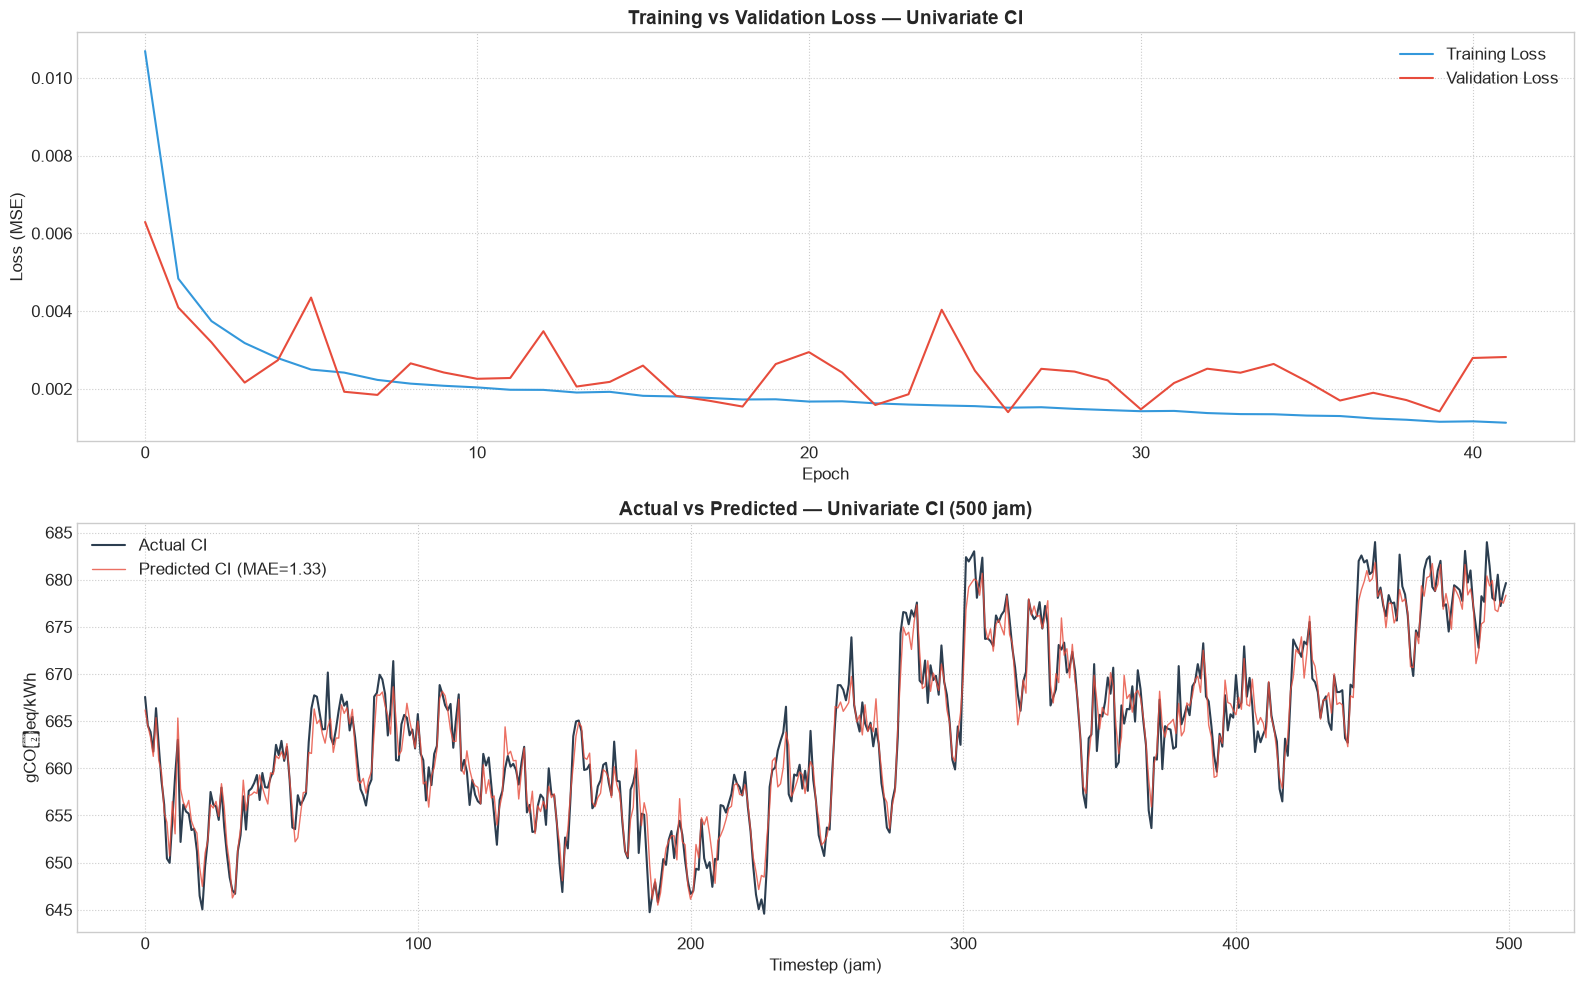

In [15]:
# Plot Model 1
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Loss curve
axes[0].plot(history_uni_ci.history['loss'], label='Training Loss', color='#3498db')
axes[0].plot(history_uni_ci.history['val_loss'], label='Validation Loss', color='#e74c3c')
axes[0].set_title('Training vs Validation Loss — Univariate CI', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# Actual vs Predicted
plot_hours = min(500, len(y_test_uci_actual))
axes[1].plot(y_test_uci_actual[:plot_hours], label='Actual CI', color='#2c3e50', linewidth=1.5)
axes[1].plot(y_pred_uci[:plot_hours], label=f'Predicted CI (MAE={metrics_uni_ci["MAE"]:.2f})', 
             color='#e74c3c', linewidth=1, alpha=0.8)
axes[1].set_title(f'Actual vs Predicted — Univariate CI ({plot_hours} jam)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Timestep (jam)')
axes[1].set_ylabel('gCO₂eq/kWh')
axes[1].legend()
axes[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---

## Model 2 — Univariate LSTM (RE)

Target: **Renewable Energy Percentage** saja. CI tidak digunakan sebagai input.

In [16]:
# === Model 2: Univariate LSTM untuk Renewable Energy ===

print("=" * 60)
print("MODEL 2: UNIVARIATE LSTM — RENEWABLE ENERGY")
print("=" * 60)

# Split & Scale
loader_uni_re = TimeSeriesDataLoader()
train_uni_re, test_uni_re = loader_uni_re.split_and_scale(
    df_features, 
    feature_cols=feature_cols_uni_re, 
    target_cols=target_cols_uni_re, 
    train_ratio=TRAIN_RATIO
)

# Create sliding windows
X_train_ure, y_train_ure = loader_uni_re.create_sliding_window(
    train_uni_re, 
    target_cols=target_cols_uni_re, 
    look_back=LOOK_BACK, 
    forecast_horizon=FORECAST_HORIZON
)
X_test_ure, y_test_ure = loader_uni_re.create_sliding_window(
    test_uni_re, 
    target_cols=target_cols_uni_re, 
    look_back=LOOK_BACK, 
    forecast_horizon=FORECAST_HORIZON
)

print(f"\nX_train: {X_train_ure.shape}, y_train: {y_train_ure.shape}")
print(f"X_test:  {X_test_ure.shape}, y_test:  {y_test_ure.shape}")

MODEL 2: UNIVARIATE LSTM — RENEWABLE ENERGY
  Split: Train=13996, Test=3500
  Sliding window: X=(13972, 24, 48), y=(13972,)
  Sliding window: X=(3476, 24, 48), y=(3476,)

X_train: (13972, 24, 48), y_train: (13972,)
X_test:  (3476, 24, 48), y_test:  (3476,)


In [17]:
# Build & Train Model 2
model_uni_re = LSTMForecaster(
    sequence_length=LOOK_BACK,
    n_features=X_train_ure.shape[2],
    n_outputs=1,
    model_dir='../saved_models/'
)

model_uni_re.build_model(
    units=64,
    n_layers=1,
    dropout_rate=0.2,
    learning_rate=0.001
)

history_uni_re = model_uni_re.train(
    X_train_ure, y_train_ure,
    X_test_ure, y_test_ure,
    epochs=100,
    batch_size=32,
    patience=15,
    model_name='univariate_re_baseline.keras'
)


Model built: 1 LSTM layer(s), 64 units, 1 output(s)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,041 (121.25 KB)

 Trainable params: 31,041 (121.25 KB)

 Non-trainable params: 0 (0.00 B)


Training... Model terbaik akan disimpan di: ../saved_models/univariate_re_baseline.keras
Epoch 1/100
428/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - mae: 0.0712
Epoch 1: val_loss improved from None to 0.00254, saving model to ../saved_models/univariate_re_baseline.keras

Epoch 1: finished saving model to ../saved_models/univariate_re_baseline.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0098 - mae: 0.0708 - val_loss: 0.0025 - val_mae: 0.0394
Epoch 2/100
427/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0457
Epoch 2: val_loss did not improve from 0.00254
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0034 - mae: 0.0457 - val_loss: 0.0026 - val_mae: 0.0406
Epoch 3/100
434/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mae: 0.0396
Epoch 3: val_loss improved from 0.00254 to 0.00224, saving model to ../saved_models/univariate_re_baseline.keras

Epoch 3: finished saving model to ../saved_models/univariate_re_baseline.keras
437/437 ━━━━━━━━━━━━

In [18]:
# Evaluasi Model 2
y_pred_ure_scaled = model_uni_re.predict(X_test_ure)

# Inverse transform
y_pred_ure = loader_uni_re.inverse_transform_predictions(
    y_pred_ure_scaled, target_cols_uni_re, feature_cols_uni_re
)
y_test_ure_actual = loader_uni_re.inverse_transform_predictions(
    y_test_ure.reshape(-1, 1), target_cols_uni_re, feature_cols_uni_re
)

# Hitung metrics
metrics_uni_re = evaluator.calculate_metrics(y_test_ure_actual.flatten(), y_pred_ure.flatten())

print("\n" + "=" * 50)
print("HASIL EVALUASI: Univariate LSTM — Renewable Energy")
print("=" * 50)
for k, v in metrics_uni_re.items():
    print(f"  {k}: {v}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

HASIL EVALUASI: Univariate LSTM — Renewable Energy
  RMSE: 0.2257
  MAE: 0.1675
  MAPE (%): 1.0582
  MSE: 0.0509


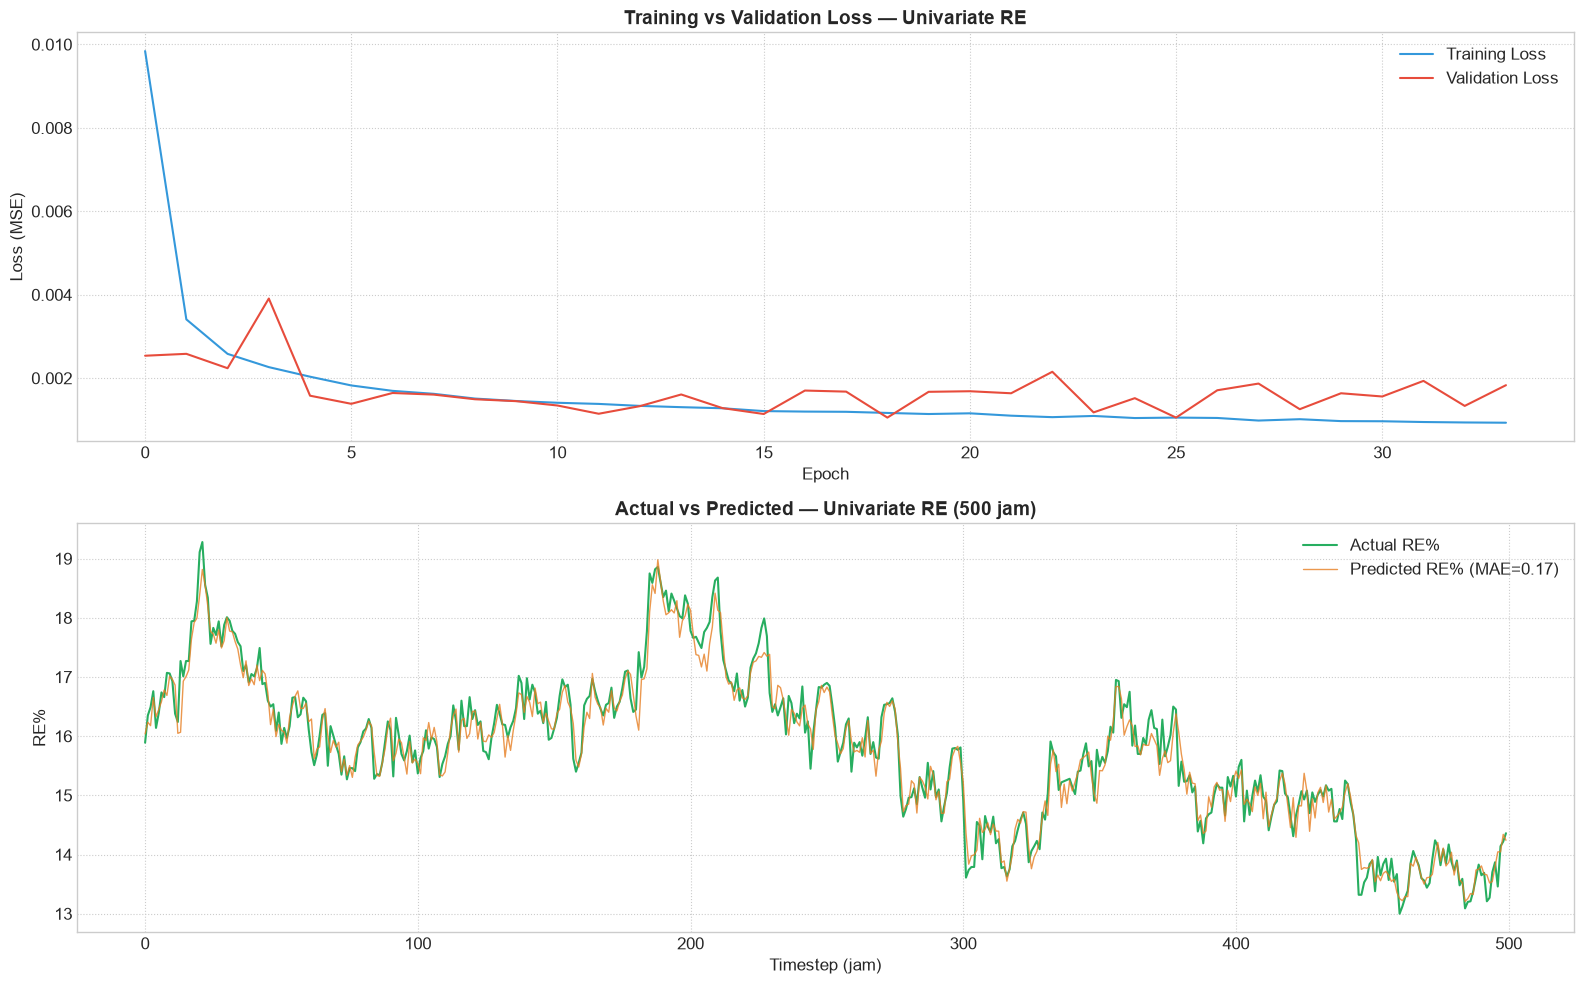

In [19]:
# Plot Model 2
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Loss curve
axes[0].plot(history_uni_re.history['loss'], label='Training Loss', color='#3498db')
axes[0].plot(history_uni_re.history['val_loss'], label='Validation Loss', color='#e74c3c')
axes[0].set_title('Training vs Validation Loss — Univariate RE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# Actual vs Predicted
plot_hours = min(500, len(y_test_ure_actual))
axes[1].plot(y_test_ure_actual[:plot_hours], label='Actual RE%', color='#27ae60', linewidth=1.5)
axes[1].plot(y_pred_ure[:plot_hours], label=f'Predicted RE% (MAE={metrics_uni_re["MAE"]:.2f})', 
             color='#e67e22', linewidth=1, alpha=0.8)
axes[1].set_title(f'Actual vs Predicted — Univariate RE ({plot_hours} jam)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Timestep (jam)')
axes[1].set_ylabel('RE%')
axes[1].legend()
axes[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---

## Model 3 — Multivariate LSTM (CI & RE)

Input: CI + RE + semua lags + semua MSTL + time features  
Output: CI dan RE secara bersamaan (2 output)

In [20]:
# === Model 3: Multivariate LSTM (CI + RE) ===

print("=" * 60)
print("MODEL 3: MULTIVARIATE LSTM — CI & RE")
print("=" * 60)

# Split & Scale
loader_multi = TimeSeriesDataLoader()
train_multi, test_multi = loader_multi.split_and_scale(
    df_features, 
    feature_cols=feature_cols_multi, 
    target_cols=target_cols_multi, 
    train_ratio=TRAIN_RATIO
)

# Create sliding windows
X_train_m, y_train_m = loader_multi.create_sliding_window(
    train_multi, 
    target_cols=target_cols_multi, 
    look_back=LOOK_BACK, 
    forecast_horizon=FORECAST_HORIZON
)
X_test_m, y_test_m = loader_multi.create_sliding_window(
    test_multi, 
    target_cols=target_cols_multi, 
    look_back=LOOK_BACK, 
    forecast_horizon=FORECAST_HORIZON
)

print(f"\nX_train: {X_train_m.shape}, y_train: {y_train_m.shape}")
print(f"X_test:  {X_test_m.shape}, y_test:  {y_test_m.shape}")

MODEL 3: MULTIVARIATE LSTM — CI & RE
  Split: Train=13996, Test=3500
  Sliding window: X=(13972, 24, 90), y=(13972, 2)
  Sliding window: X=(3476, 24, 90), y=(3476, 2)

X_train: (13972, 24, 90), y_train: (13972, 2)
X_test:  (3476, 24, 90), y_test:  (3476, 2)


In [21]:
# Build & Train Model 3
model_multi = LSTMForecaster(
    sequence_length=LOOK_BACK,
    n_features=X_train_m.shape[2],
    n_outputs=2,  # CI + RE
    model_dir='../saved_models/'
)

model_multi.build_model(
    units=64,
    n_layers=1,
    dropout_rate=0.2,
    learning_rate=0.001
)

history_multi = model_multi.train(
    X_train_m, y_train_m,
    X_test_m, y_test_m,
    epochs=100,
    batch_size=32,
    patience=15,
    model_name='multivariate_baseline.keras'
)


Model built: 1 LSTM layer(s), 64 units, 2 output(s)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        39,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,826 (163.38 KB)

 Trainable params: 41,826 (163.38 KB)

 Non-trainable params: 0 (0.00 B)


Training... Model terbaik akan disimpan di: ../saved_models/multivariate_baseline.keras
Epoch 1/100
427/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - mae: 0.0754
Epoch 1: val_loss improved from None to 0.00447, saving model to ../saved_models/multivariate_baseline.keras

Epoch 1: finished saving model to ../saved_models/multivariate_baseline.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0099 - mae: 0.0750 - val_loss: 0.0045 - val_mae: 0.0537
Epoch 2/100
430/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - mae: 0.0512
Epoch 2: val_loss improved from 0.00447 to 0.00319, saving model to ../saved_models/multivariate_baseline.keras

Epoch 2: finished saving model to ../saved_models/multivariate_baseline.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0043 - mae: 0.0511 - val_loss: 0.0032 - val_mae: 0.0446
Epoch 3/100
426/437 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0443
Epoch 3: val_loss improved from 0.00319 to 0.00244, saving model to ../s

In [22]:
# Evaluasi Model 3
y_pred_m_scaled = model_multi.predict(X_test_m)

# Inverse transform
y_pred_m = loader_multi.inverse_transform_predictions(
    y_pred_m_scaled, target_cols_multi, feature_cols_multi
)
y_test_m_actual = loader_multi.inverse_transform_predictions(
    y_test_m, target_cols_multi, feature_cols_multi
)

# Metrics untuk CI (dari multivariate)
metrics_multi_ci = evaluator.calculate_metrics(y_test_m_actual[:, 0], y_pred_m[:, 0])

# Metrics untuk RE (dari multivariate)
metrics_multi_re = evaluator.calculate_metrics(y_test_m_actual[:, 1], y_pred_m[:, 1])

print("\n" + "=" * 50)
print("HASIL EVALUASI: Multivariate LSTM — Carbon Intensity")
print("=" * 50)
for k, v in metrics_multi_ci.items():
    print(f"  {k}: {v}")

print("\n" + "=" * 50)
print("HASIL EVALUASI: Multivariate LSTM — Renewable Energy")
print("=" * 50)
for k, v in metrics_multi_re.items():
    print(f"  {k}: {v}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

HASIL EVALUASI: Multivariate LSTM — Carbon Intensity
  RMSE: 1.6521
  MAE: 1.2704
  MAPE (%): 0.1916
  MSE: 2.7295

HASIL EVALUASI: Multivariate LSTM — Renewable Energy
  RMSE: 0.2006
  MAE: 0.1529
  MAPE (%): 0.9678
  MSE: 0.0402


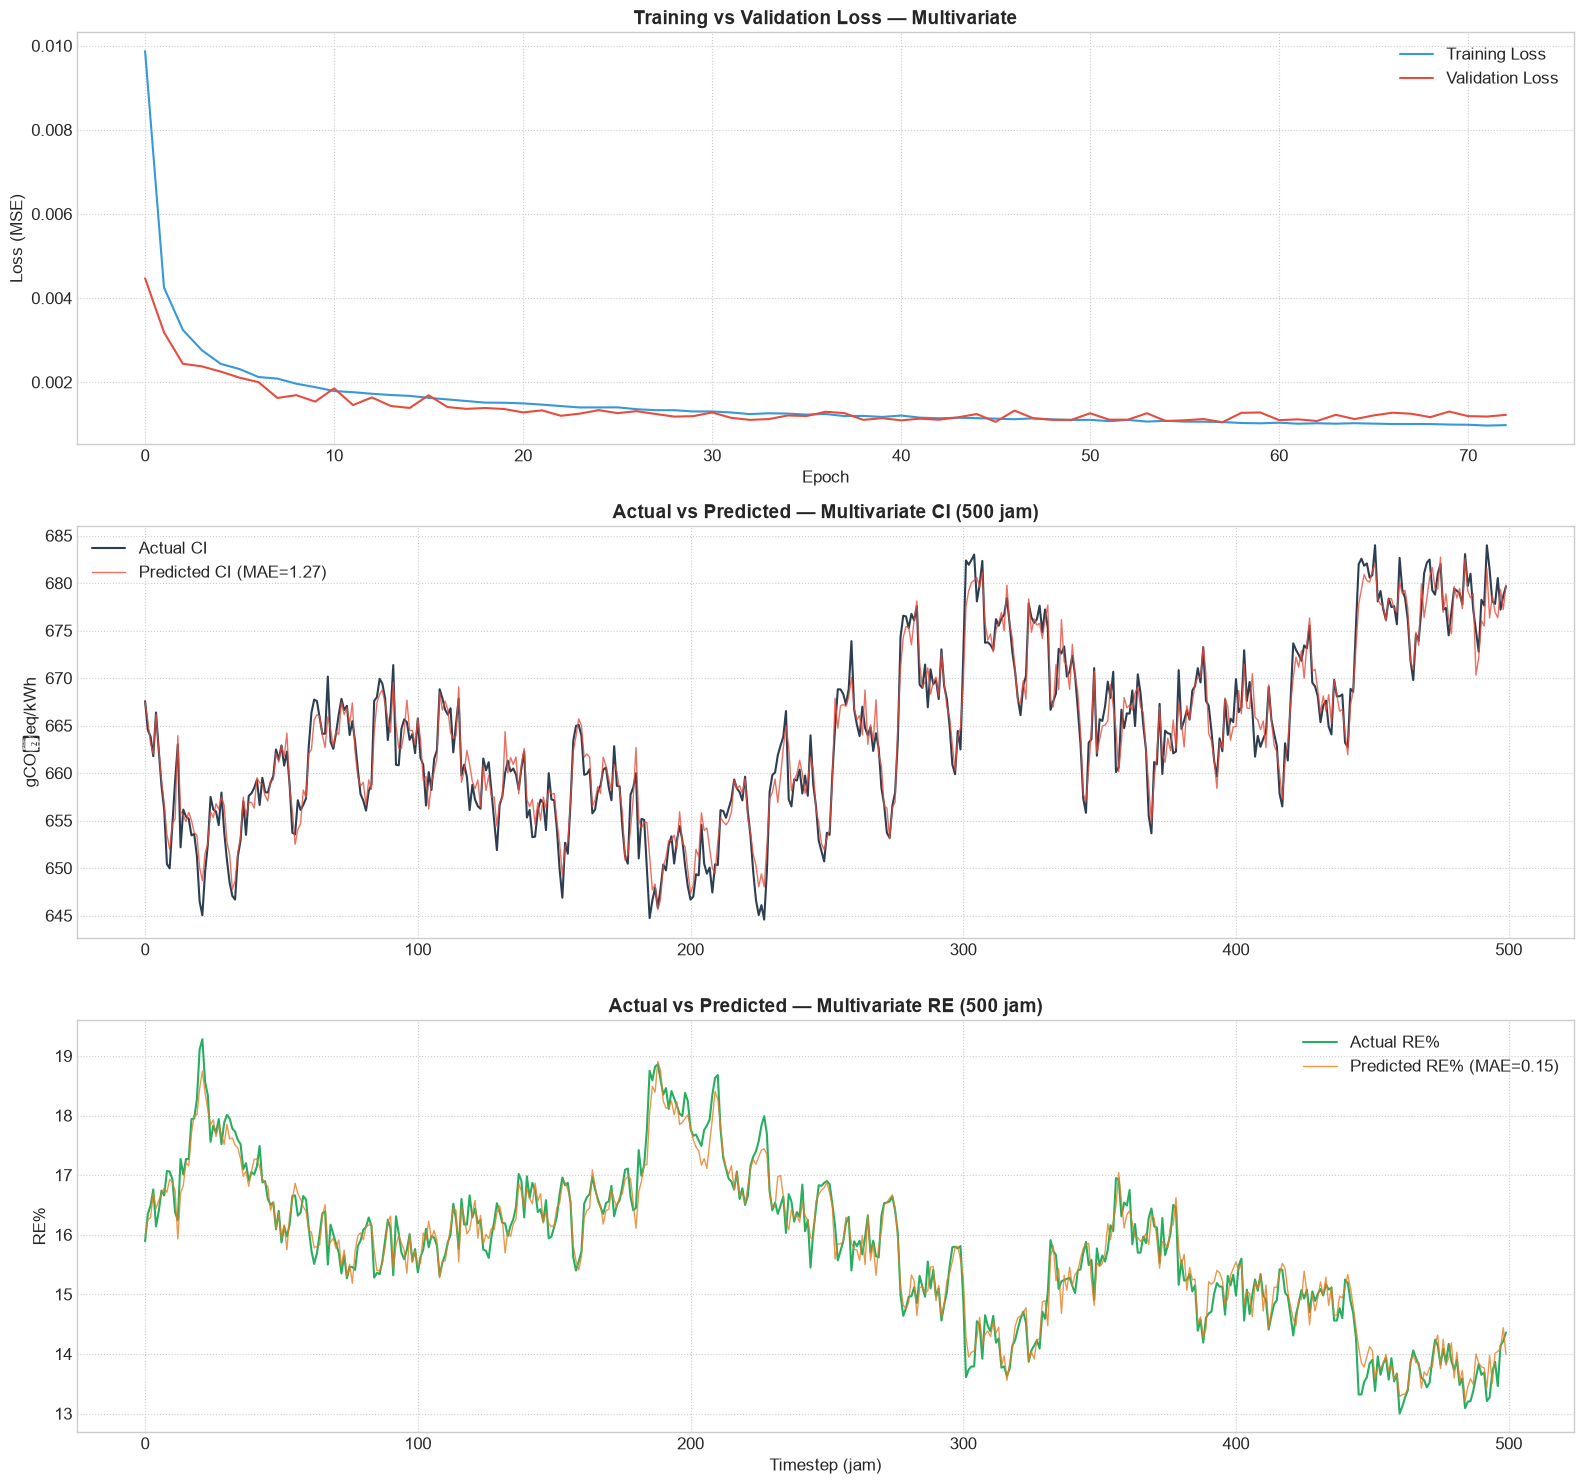

In [23]:
# Plot Model 3
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# Loss curve
axes[0].plot(history_multi.history['loss'], label='Training Loss', color='#3498db')
axes[0].plot(history_multi.history['val_loss'], label='Validation Loss', color='#e74c3c')
axes[0].set_title('Training vs Validation Loss — Multivariate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# CI actual vs predicted
plot_hours = min(500, len(y_test_m_actual))
axes[1].plot(y_test_m_actual[:plot_hours, 0], label='Actual CI', color='#2c3e50', linewidth=1.5)
axes[1].plot(y_pred_m[:plot_hours, 0], label=f'Predicted CI (MAE={metrics_multi_ci["MAE"]:.2f})', 
             color='#e74c3c', linewidth=1, alpha=0.8)
axes[1].set_title(f'Actual vs Predicted — Multivariate CI ({plot_hours} jam)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('gCO₂eq/kWh')
axes[1].legend()
axes[1].grid(True, linestyle=':')

# RE actual vs predicted
axes[2].plot(y_test_m_actual[:plot_hours, 1], label='Actual RE%', color='#27ae60', linewidth=1.5)
axes[2].plot(y_pred_m[:plot_hours, 1], label=f'Predicted RE% (MAE={metrics_multi_re["MAE"]:.2f})', 
             color='#e67e22', linewidth=1, alpha=0.8)
axes[2].set_title(f'Actual vs Predicted — Multivariate RE ({plot_hours} jam)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Timestep (jam)')
axes[2].set_ylabel('RE%')
axes[2].legend()
axes[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---

##  Model Comparison

In [24]:
# === Perbandingan 3 Model ===

comparison_data = {
    'Model': [
        'Univariate CI', 
        'Univariate RE', 
        'Multivariate CI', 
        'Multivariate RE'
    ],
    'Target': ['CI', 'RE', 'CI', 'RE'],
    'MAE': [
        metrics_uni_ci['MAE'], 
        metrics_uni_re['MAE'], 
        metrics_multi_ci['MAE'], 
        metrics_multi_re['MAE']
    ],
    'RMSE': [
        metrics_uni_ci['RMSE'], 
        metrics_uni_re['RMSE'], 
        metrics_multi_ci['RMSE'], 
        metrics_multi_re['RMSE']
    ],
    'MAPE (%)': [
        metrics_uni_ci['MAPE (%)'], 
        metrics_uni_re['MAPE (%)'], 
        metrics_multi_ci['MAPE (%)'], 
        metrics_multi_re['MAPE (%)']
    ],
    'MSE': [
        metrics_uni_ci['MSE'], 
        metrics_uni_re['MSE'], 
        metrics_multi_ci['MSE'], 
        metrics_multi_re['MSE']
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 70)
print("PERBANDINGAN SEMUA MODEL BASELINE")
print("=" * 70)
print(df_comparison.to_string(index=False))
print("\nNote: Untuk target CI, bandingkan Univariate CI vs Multivariate CI")
print("      Untuk target RE, bandingkan Univariate RE vs Multivariate RE")


PERBANDINGAN SEMUA MODEL BASELINE
          Model Target    MAE   RMSE  MAPE (%)    MSE
  Univariate CI     CI 1.3328 1.7385    0.2008 3.0223
  Univariate RE     RE 0.1675 0.2257    1.0582 0.0509
Multivariate CI     CI 1.2704 1.6521    0.1916 2.7295
Multivariate RE     RE 0.1529 0.2006    0.9678 0.0402

Note: Untuk target CI, bandingkan Univariate CI vs Multivariate CI
      Untuk target RE, bandingkan Univariate RE vs Multivariate RE


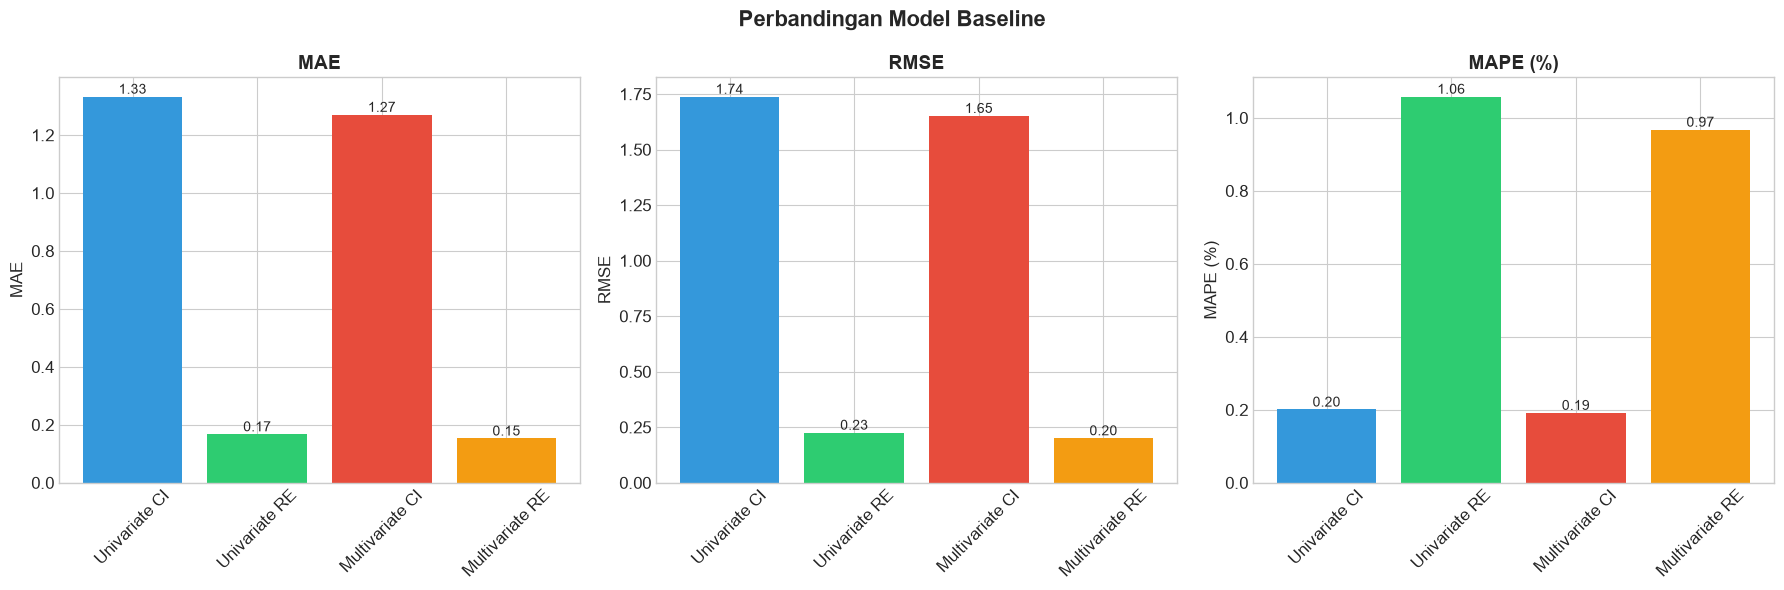

In [25]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(df_comparison['Model'], df_comparison[metric], color=colors)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, df_comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Model Baseline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Tentukan model terbaik untuk CI dan RE
ci_models = df_comparison[df_comparison['Target'] == 'CI']
re_models = df_comparison[df_comparison['Target'] == 'RE']

best_ci_model = ci_models.loc[ci_models['MAE'].idxmin(), 'Model']
best_re_model = re_models.loc[re_models['MAE'].idxmin(), 'Model']

print(f"\n Model terbaik untuk CI (berdasarkan MAE): {best_ci_model}")
print(f" Model terbaik untuk RE (berdasarkan MAE): {best_re_model}")
print(f"\nModel akan di-tune dengan Optuna.")


 Model terbaik untuk CI (berdasarkan MAE): Multivariate CI
 Model terbaik untuk RE (berdasarkan MAE): Multivariate RE

Model akan di-tune dengan Optuna.


---

##  Optuna Hyperparameter Tuning

Tuning model terbaik untuk mendapatkan hyperparameter paling optimal.

**Search Space**:
- `units`: 32-256
- `n_layers`: 1-3
- `dropout_rate`: 0.1-0.5
- `learning_rate`: 1e-4 - 1e-2
- `batch_size`: 16, 32, 64, 128
- `dense_units`: 16, 32, 64

In [ ]:
import optuna
from tensorflow.keras.backend import clear_session

# === Optuna Objective Function ===

def create_optuna_objective(X_train, y_train, X_val, y_val, n_outputs, model_dir):
    """
    Factory function yang membuat objective function untuk Optuna.
    fungsi ini dapat dipakai untuk model mana saja (uni CI, uni RE, multi).
    """
    def objective(trial):
        clear_session()
        
        # Hyperparameter search space
        units = trial.suggest_int('units', 32, 256, step=32)
        n_layers = trial.suggest_int('n_layers', 1, 3)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.05)
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
        dense_units = trial.suggest_categorical('dense_units', [16, 32, 64])
        
        # Build model
        forecaster = LSTMForecaster(
            sequence_length=LOOK_BACK,
            n_features=X_train.shape[2],
            n_outputs=n_outputs,
            model_dir=model_dir
        )
        
        forecaster.build_model(
            units=units,
            n_layers=n_layers,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
            dense_units=dense_units
        )
        
        # Train (dengan reduced verbosity)
        history = forecaster.train(
            X_train, y_train,
            X_val, y_val,
            epochs=50,
            batch_size=batch_size,
            patience=10,
            model_name=f'optuna_trial_{trial.number}.keras',
            verbose=0
        )
        
        # Return best validation loss
        best_val_loss = min(history.history['val_loss'])
        
        return best_val_loss
    
    return objective

In [28]:
# === Tuning Model Terbaik CI ===

print("\n" + "=" * 60)
print(f"OPTUNA TUNING: {best_ci_model} (Target: CI)")
print("=" * 60)

# Pilih data berdasarkan model terbaik
if 'Univariate' in best_ci_model:
    X_tr, y_tr = X_train_uci, y_train_uci
    X_te, y_te = X_test_uci, y_test_uci
    n_out = 1
else:
    X_tr, y_tr = X_train_m, y_train_m
    X_te, y_te = X_test_m, y_test_m
    n_out = 2

# Buat dan jalankan study
study_ci = optuna.create_study(direction='minimize', study_name='lstm_ci_tuning')
objective_ci = create_optuna_objective(X_tr, y_tr, X_te, y_te, n_out, '../saved_models/optuna/')

study_ci.optimize(objective_ci, n_trials=30, show_progress_bar=True)

print(f"\n Best trial (CI):")
print(f"  Value (val_loss): {study_ci.best_trial.value:.6f}")
print(f"  Params: {study_ci.best_trial.params}")

[I 2026-07-29 08:36:49,059] A new study created in memory with name: lstm_ci_tuning



OPTUNA TUNING: Multivariate CI (Target: CI)


  0%|          | 0/30 [00:00<?, ?it/s]


Model built: 1 LSTM layer(s), 96 units, 2 output(s)


Model: "sequential"

...

 Trainable params: 814,946 (3.11 MB)

 Non-trainable params: 0 (0.00 B)


Training... Model terbaik akan disimpan di: ../saved_models/optuna/optuna_trial_29.keras

Epoch 1: val_loss improved from None to 0.01169, saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 1: finished saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 2: val_loss improved from 0.01169 to 0.00687, saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 2: finished saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 3: val_loss improved from 0.00687 to 0.00431, saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 3: finished saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 4: val_loss did not improve from 0.00431

Epoch 5: val_loss improved from 0.00431 to 0.00354, saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 5: finished saving model to ../saved_models/optuna/optuna_trial_29.keras

Epoch 6: val_loss improved from 0.00354 to 0.00342, saving model to ../saved_models/optu

Best trial: 21. Best value: 0.000749364: 100%|██████████| 30/30 [6:07:20<00:00, 734.67s/it]

[I 2026-07-29 14:44:09,287] Trial 29 finished with value: 0.0008518006652593613 and parameters: {'units': 192, 'n_layers': 3, 'dropout_rate': 0.1, 'learning_rate': 0.002340685221652974, 'batch_size': 128, 'dense_units': 32}. Best is trial 21 with value: 0.0007493644952774048.

🏆 Best trial (CI):
  Value (val_loss): 0.000749
  Params: {'units': 192, 'n_layers': 3, 'dropout_rate': 0.15000000000000002, 'learning_rate': 0.0011989398434299333, 'batch_size': 64, 'dense_units': 32}


In [29]:
# === Train Final Model CI dengan Best Params ===

best_params_ci = study_ci.best_trial.params
print(f"Training final model CI dengan params: {best_params_ci}")

from tensorflow.keras.backend import clear_session
clear_session()

final_model_ci = LSTMForecaster(
    sequence_length=LOOK_BACK,
    n_features=X_tr.shape[2],
    n_outputs=n_out,
    model_dir='../saved_models/'
)

final_model_ci.build_model(
    units=best_params_ci['units'],
    n_layers=best_params_ci['n_layers'],
    dropout_rate=best_params_ci['dropout_rate'],
    learning_rate=best_params_ci['learning_rate'],
    dense_units=best_params_ci['dense_units']
)

history_final_ci = final_model_ci.train(
    X_tr, y_tr,
    X_te, y_te,
    epochs=100,
    batch_size=best_params_ci['batch_size'],
    patience=15,
    model_name='optuna_best_ci.keras'
)

Training final model CI dengan params: {'units': 192, 'n_layers': 3, 'dropout_rate': 0.15000000000000002, 'learning_rate': 0.0011989398434299333, 'batch_size': 64, 'dense_units': 32}

Model built: 3 LSTM layer(s), 192 units, 2 output(s)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 192)        │       217,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 192)        │       295,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 192)            │       295,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,946 (3.11 MB)

 Trainable params: 814,946 (3.11 MB)

 Non-trainable params: 0 (0.00 B)


Training... Model terbaik akan disimpan di: ../saved_models/optuna_best_ci.keras
Epoch 1/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0138 - mae: 0.0835
Epoch 1: val_loss improved from None to 0.00887, saving model to ../saved_models/optuna_best_ci.keras

Epoch 1: finished saving model to ../saved_models/optuna_best_ci.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - loss: 0.0138 - mae: 0.0835 - val_loss: 0.0089 - val_mae: 0.0732
Epoch 2/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0054 - mae: 0.0579
Epoch 2: val_loss improved from 0.00887 to 0.00364, saving model to ../saved_models/optuna_best_ci.keras

Epoch 2: finished saving model to ../saved_models/optuna_best_ci.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - loss: 0.0054 - mae: 0.0579 - val_loss: 0.0036 - val_mae: 0.0477
Epoch 3/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0041 - mae: 0.0502
Epoch 3: val_loss improved from 0.00364 to 0.00339, saving model to ../saved_models/optuna_best_ci.k

In [30]:
# === Evaluasi Final Model CI ===

y_pred_final_ci_scaled = final_model_ci.predict(X_te)

# Pilih loader dan cols yang sesuai
if 'Univariate' in best_ci_model:
    y_pred_final_ci = loader_uni_ci.inverse_transform_predictions(
        y_pred_final_ci_scaled, target_cols_uni_ci, feature_cols_uni_ci
    )
    y_test_final_ci = loader_uni_ci.inverse_transform_predictions(
        y_te.reshape(-1, 1), target_cols_uni_ci, feature_cols_uni_ci
    )
    metrics_final_ci = evaluator.calculate_metrics(
        y_test_final_ci.flatten(), y_pred_final_ci.flatten()
    )
else:
    y_pred_final_ci = loader_multi.inverse_transform_predictions(
        y_pred_final_ci_scaled, target_cols_multi, feature_cols_multi
    )
    y_test_final_ci = loader_multi.inverse_transform_predictions(
        y_te, target_cols_multi, feature_cols_multi
    )
    metrics_final_ci = evaluator.calculate_metrics(
        y_test_final_ci[:, 0], y_pred_final_ci[:, 0]
    )

print("\n" + "=" * 60)
print("HASIL EVALUASI FINAL: Optuna-Tuned Model — CI")
print("=" * 60)
for k, v in metrics_final_ci.items():
    print(f"  {k}: {v}")

print(f"\nPerbandingan MAE:")
print(f"  Baseline: {metrics_uni_ci['MAE']}")
print(f"  Optuna:   {metrics_final_ci['MAE']}")
improvement = ((metrics_uni_ci['MAE'] - metrics_final_ci['MAE']) / metrics_uni_ci['MAE']) * 100
print(f"  Improvement: {improvement:.2f}%")

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

HASIL EVALUASI FINAL: Optuna-Tuned Model — CI
  RMSE: 1.3289
  MAE: 1.0165
  MAPE (%): 0.1532
  MSE: 1.7659

Perbandingan MAE:
  Baseline: 1.3328
  Optuna:   1.0165
  Improvement: 23.73%


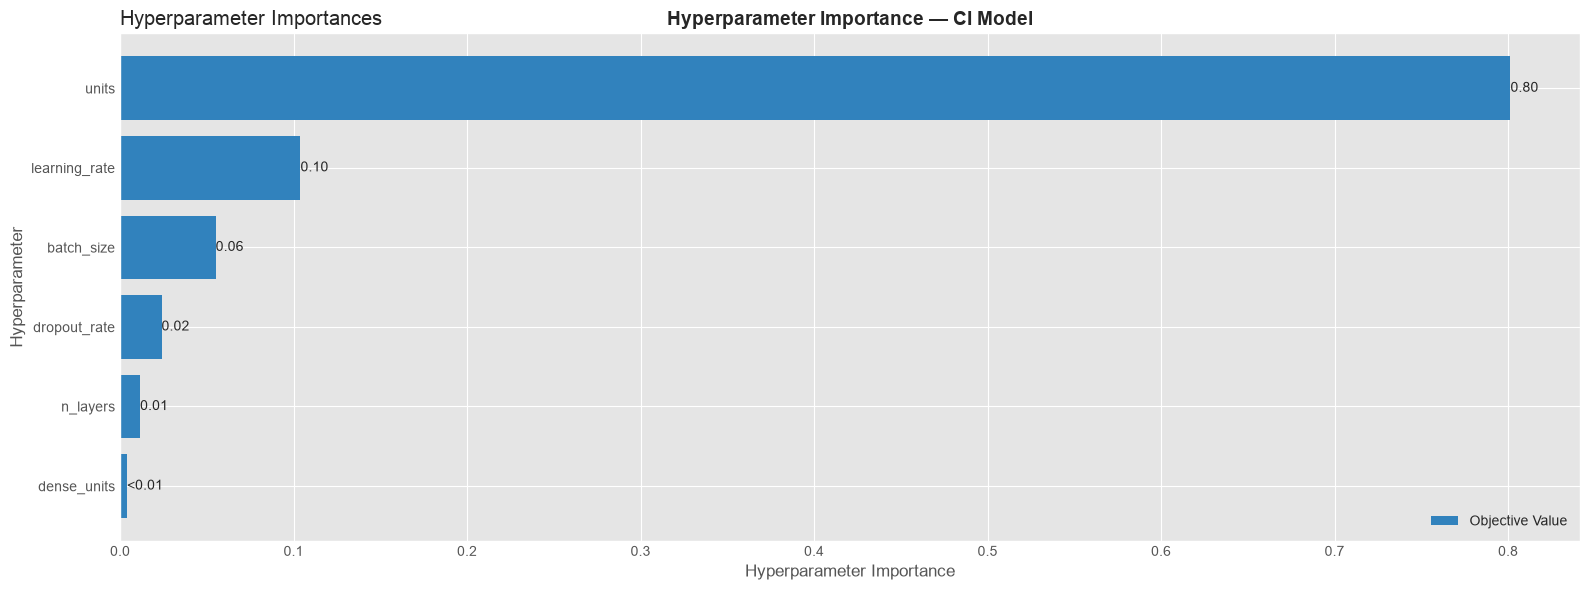

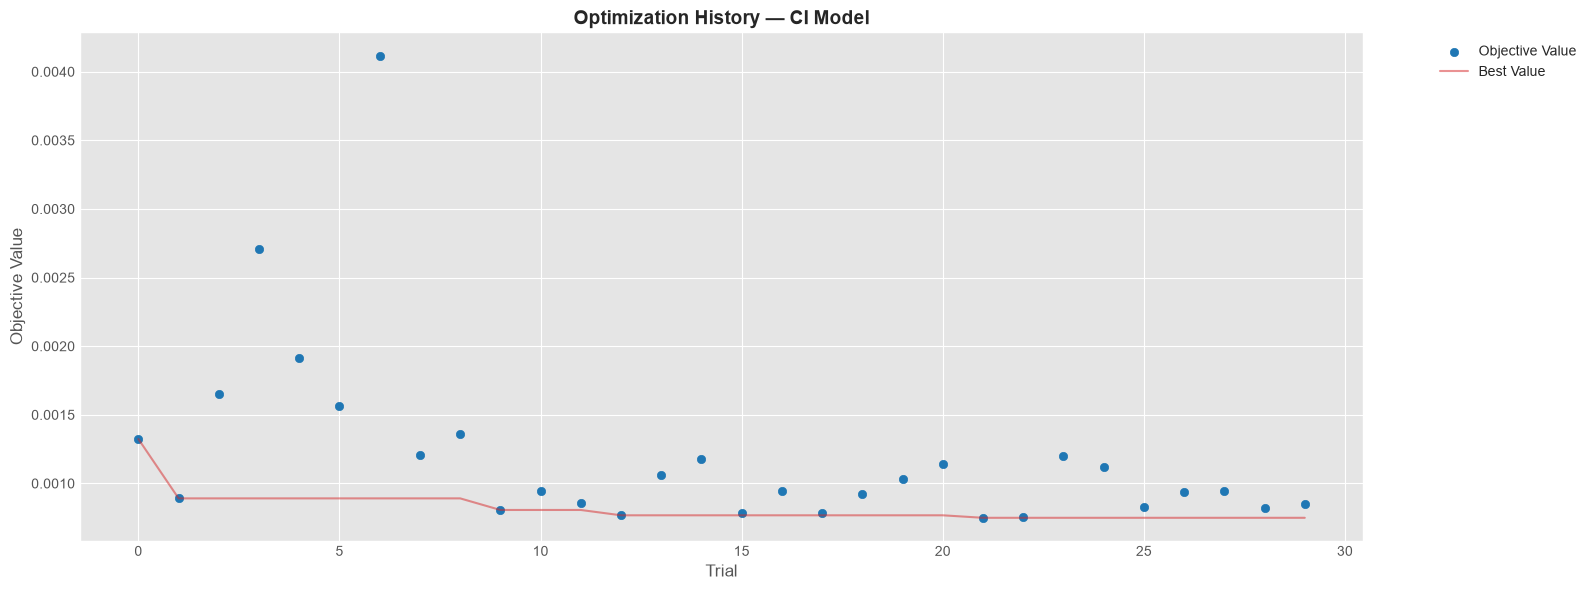

In [31]:
# === Optuna Visualization ===

# Parameter importance
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(study_ci)
    plt.title('Hyperparameter Importance — CI Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Cannot plot param importances: {e}")

# Optimization history
try:
    fig = optuna.visualization.matplotlib.plot_optimization_history(study_ci)
    plt.title('Optimization History — CI Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Cannot plot optimization history: {e}")

In [32]:
# === Final Comparison: Baseline vs Optuna ===

final_comparison = {
    'Model': ['Uni CI (Baseline)', 'Uni RE (Baseline)', 'Multi CI (Baseline)', 'Multi RE (Baseline)', 
              f'{best_ci_model} (Optuna)'],
    'Target': ['CI', 'RE', 'CI', 'RE', 'CI'],
    'MAE': [
        metrics_uni_ci['MAE'], metrics_uni_re['MAE'], 
        metrics_multi_ci['MAE'], metrics_multi_re['MAE'],
        metrics_final_ci['MAE']
    ],
    'RMSE': [
        metrics_uni_ci['RMSE'], metrics_uni_re['RMSE'], 
        metrics_multi_ci['RMSE'], metrics_multi_re['RMSE'],
        metrics_final_ci['RMSE']
    ],
    'MAPE (%)': [
        metrics_uni_ci['MAPE (%)'], metrics_uni_re['MAPE (%)'], 
        metrics_multi_ci['MAPE (%)'], metrics_multi_re['MAPE (%)'],
        metrics_final_ci['MAPE (%)']
    ],
    'MSE': [
        metrics_uni_ci['MSE'], metrics_uni_re['MSE'], 
        metrics_multi_ci['MSE'], metrics_multi_re['MSE'],
        metrics_final_ci['MSE']
    ]
}

df_final = pd.DataFrame(final_comparison)

print("\n" + "=" * 80)
print("FINAL COMPARISON: SEMUA MODEL")
print("=" * 80)
print(df_final.to_string(index=False))


FINAL COMPARISON: SEMUA MODEL
                   Model Target    MAE   RMSE  MAPE (%)    MSE
       Uni CI (Baseline)     CI 1.3328 1.7385    0.2008 3.0223
       Uni RE (Baseline)     RE 0.1675 0.2257    1.0582 0.0509
     Multi CI (Baseline)     CI 1.2704 1.6521    0.1916 2.7295
     Multi RE (Baseline)     RE 0.1529 0.2006    0.9678 0.0402
Multivariate CI (Optuna)     CI 1.0165 1.3289    0.1532 1.7659


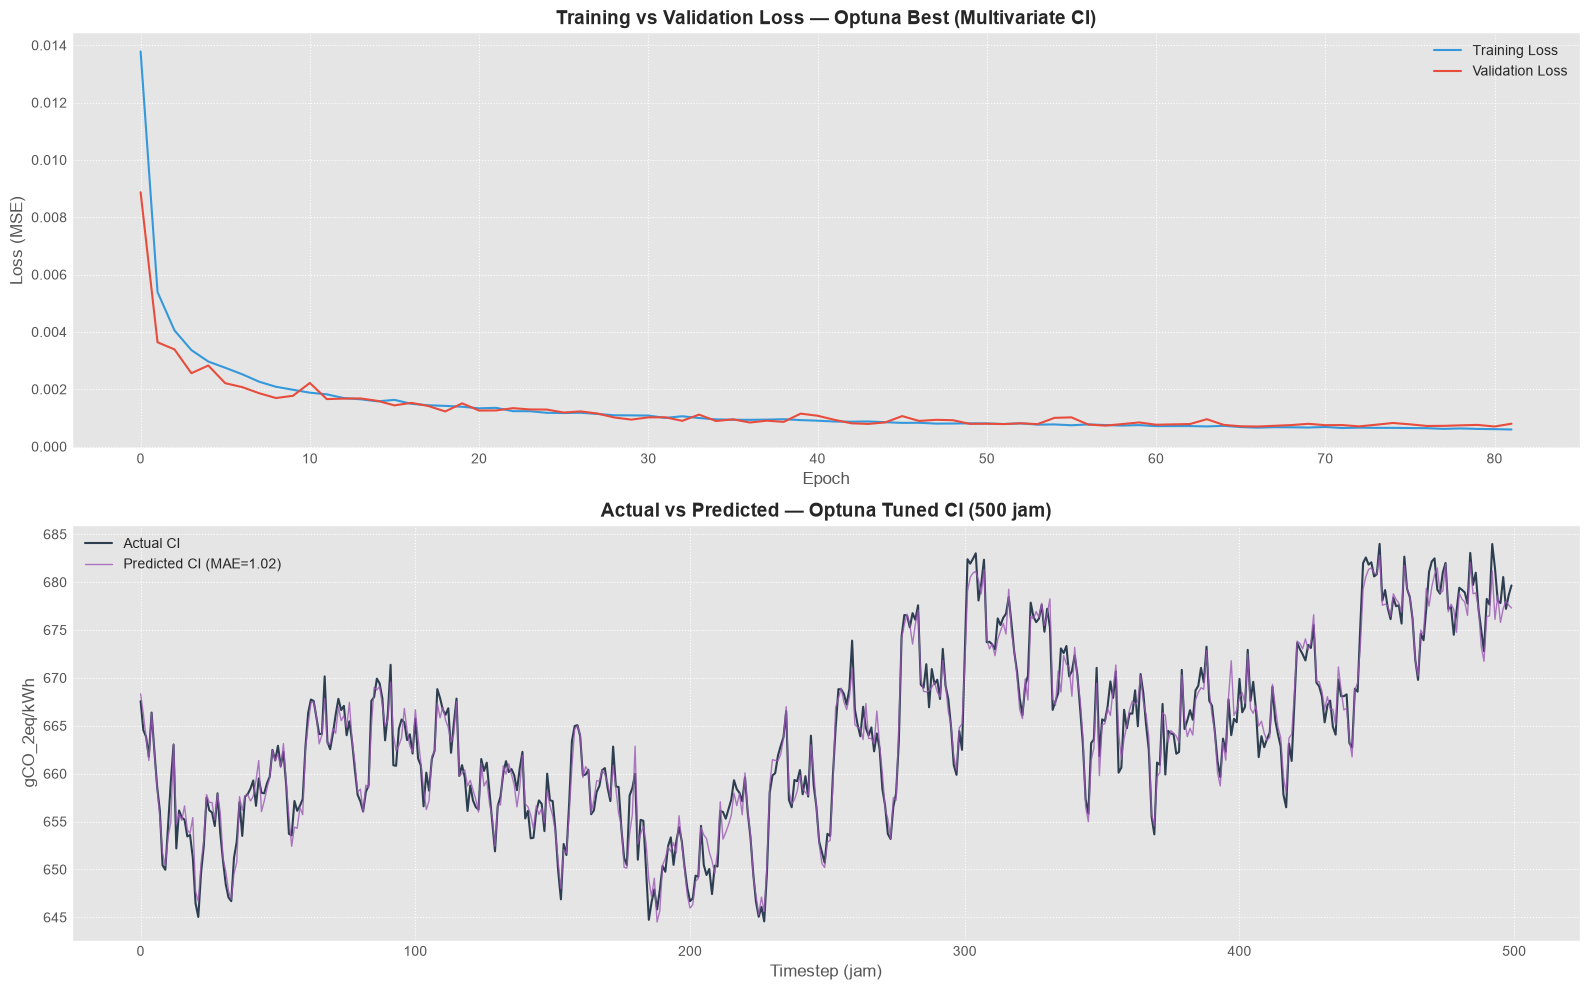


Pipeline selesai! Model terbaik tersimpan di ../saved_models/


In [33]:
# Plot Final Comparison

if 'Univariate' in best_ci_model:
    y_pred_to_plot = y_pred_final_ci.flatten()
    y_test_to_plot = y_test_final_ci.flatten()
else:
    y_pred_to_plot = y_pred_final_ci[:, 0]
    y_test_to_plot = y_test_final_ci[:, 0]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Loss
axes[0].plot(history_final_ci.history['loss'], label='Training Loss', color='#3498db')
axes[0].plot(history_final_ci.history['val_loss'], label='Validation Loss', color='#e74c3c')
axes[0].set_title(f'Training vs Validation Loss — Optuna Best ({best_ci_model})', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# Actual vs Predicted
plot_hours = min(500, len(y_test_to_plot))
axes[1].plot(y_test_to_plot[:plot_hours], label='Actual CI', color='#2c3e50', linewidth=1.5)
axes[1].plot(y_pred_to_plot[:plot_hours], 
             label=f'Predicted CI (MAE={metrics_final_ci["MAE"]:.2f})', 
             color='#9b59b6', linewidth=1, alpha=0.8)
axes[1].set_title(f'Actual vs Predicted — Optuna Tuned CI ({plot_hours} jam)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Timestep (jam)')
axes[1].set_ylabel('gCO_2eq/kWh')
axes[1].legend()
axes[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

print("\nPipeline selesai! Model terbaik tersimpan di ../saved_models/")